In [1]:
# Import Libraries


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-06-05 09:34:02.934735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780652043.287561      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780652043.365523      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780652044.090880      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780652044.090916      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780652044.090920      58 computation_placer.cc:177] computation placer alr

In [2]:
#tensorflow version
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: []


2026-06-05 09:34:21.633731: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# dataset path
DATASET_PATH = "/kaggle/input/datasets/ferix01/water-pollution-classification-dataset/Water_Pollution_Dataset"

print(os.listdir(DATASET_PATH))

['Polluted', 'Clean']


In [4]:
# class distribution count
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

Polluted : 154
Clean : 147


In [5]:
# Load Dataset

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

# image resizing 
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 298 files belonging to 2 classes.
Using 209 files for training.
Found 298 files belonging to 2 classes.
Using 89 files for validation.
Classes: ['Clean', 'Polluted']


In [6]:
# Split Validation and Test

val_batches = tf.data.experimental.cardinality(temp_ds)
test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 14
Validation batches: 3
Testing batches: 3


In [8]:
# performance optimizatin

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [10]:
#Custom CNN Model

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train CNN

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5263 - loss: 0.9308 - val_accuracy: 0.4634 - val_loss: 0.7043
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 955ms/step - accuracy: 0.5120 - loss: 0.6963 - val_accuracy: 0.6585 - val_loss: 0.6895
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 946ms/step - accuracy: 0.5359 - loss: 0.7031 - val_accuracy: 0.5366 - val_loss: 0.6859
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 943ms/step - accuracy: 0.5072 - loss: 0.6869 - val_accuracy: 0.4878 - val_loss: 0.6817
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 953ms/step - accuracy: 0.5550 - loss: 0.6827 - val_accuracy: 0.4878 - val_loss: 0.6744
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 952ms/step - accuracy: 0.6077 - loss: 0.6878 - val_accuracy: 0.5854 - val_loss: 0.6865
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 946ms/step - accuracy: 0.5694 - loss: 0.6898 - val_accuracy: 0.7073 - val_loss: 0.6715
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 941ms/step - accuracy: 0.6794 - loss: 0.6643 - val_accurac

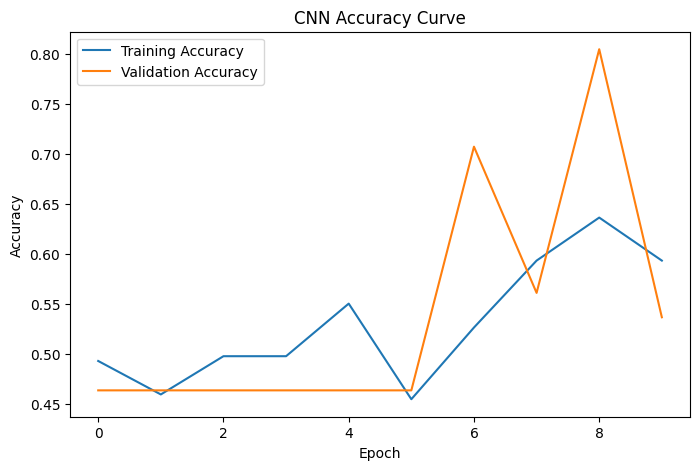

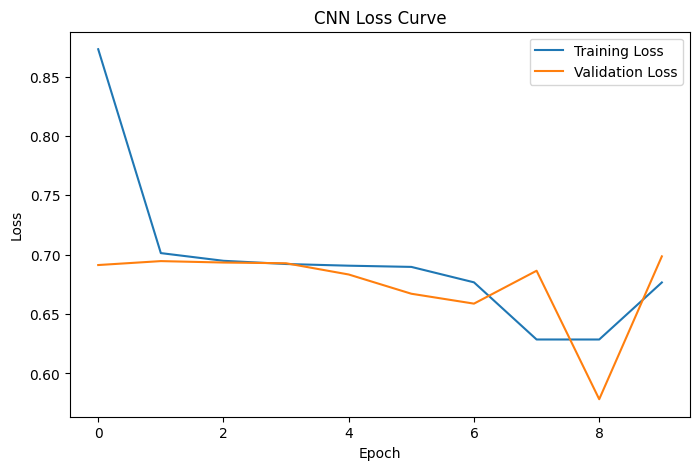

In [17]:
# Accuracy and Loss Curves

plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig('/kaggle/working/cnn_accuracy_curve.png')

plt.show()

plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('/kaggle/working/cnn_loss_curve.png')

plt.show()

In [18]:
# Evaluate CNN

cnn_loss, cnn_accuracy = cnn_model.evaluate(test_ds)
print("CNN Test Accuracy:", cnn_accuracy)
print("CNN Test Loss:", cnn_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4792 - loss: 0.7446  
CNN Test Accuracy: 0.4791666567325592
CNN Test Loss: 0.7446446418762207


In [19]:
# cnn classificaiton report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images)
    predicted_labels = (predictions > 0.5).astype("int32").flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Classification Report:
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00        25
    Polluted       0.48      1.00      0.65        23

    accuracy                           0.48        48
   macro avg       0.24      0.50      0.32        48
weighted avg       0.23      0.48      0.31        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


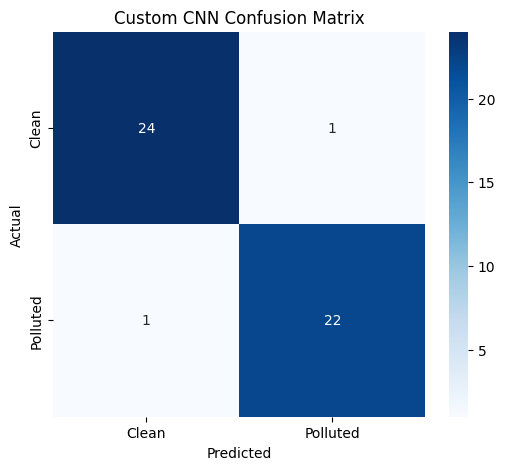

In [30]:
#Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig('/kaggle/working/cnn_confusion_matrix.png')

plt.show()

In [21]:
#MobileNetV2 transer learning

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# MobileNetV2 Train

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 524ms/step - accuracy: 0.7033 - loss: 0.7013 - val_accuracy: 0.8537 - val_loss: 0.3121
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.9187 - loss: 0.2269 - val_accuracy: 0.9268 - val_loss: 0.2070
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.8995 - loss: 0.2462 - val_accuracy: 0.8537 - val_loss: 0.3992
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 375ms/step - accuracy: 0.9043 - loss: 0.2821 - val_accuracy: 0.9024 - val_loss: 0.2670
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.9139 - loss: 0.1958 - val_accuracy: 0.9512 - val_loss: 0.0989
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 377ms/step - accuracy: 0.9330 - loss: 0.1637 - val_accuracy: 0.9512 - val_loss: 0.1679
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.9522 - loss: 0.1590 - val_accuracy: 0.9512 - val_loss: 0.1482
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.9569 - loss: 0.1186 - val_accuracy: 

In [23]:
#MobileNetV2 accuracy

mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(test_ds)

print("MobileNetV2 Test Accuracy:", mobilenet_accuracy)
print("MobileNetV2 Test Loss:", mobilenet_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 0.9583 - loss: 0.1499
MobileNetV2 Test Accuracy: 0.9583333134651184
MobileNetV2 Test Loss: 0.14989691972732544


In [24]:
# Model comparison

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [cnn_accuracy, mobilenet_accuracy],
    "Test Loss": [cnn_loss, mobilenet_loss]
})

comparison_df.to_csv("model_comparison.csv", index=False)
comparison_df

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.479167,0.744645
1,MobileNetV2,0.958333,0.149897


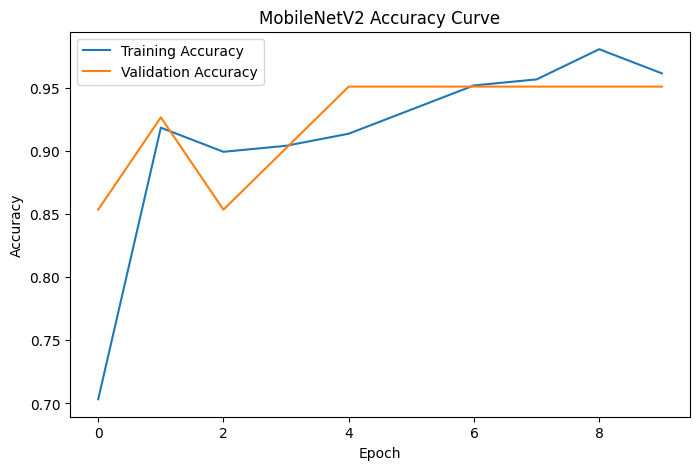

In [31]:
#MobileNetV2 Accuracy Curve

plt.figure(figsize=(8,5))
plt.plot(mobilenet_history.history['accuracy'], label='Training Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/kaggle/working/mobilenet_accuracy_curve.png')
plt.show()

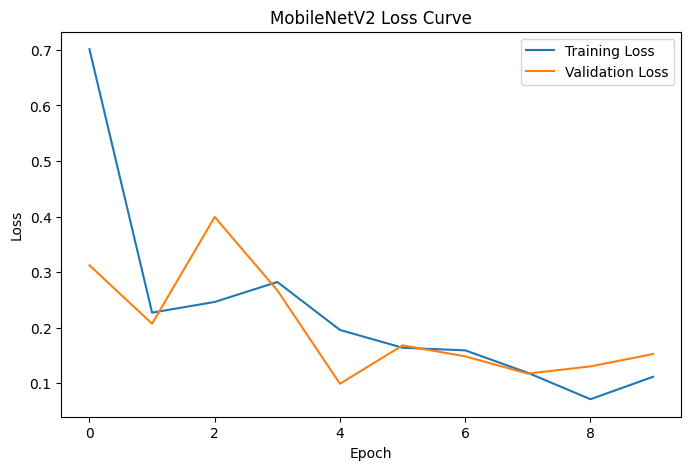

In [32]:
#MobileNetV2 Loss Curve

plt.figure(figsize=(8,5))
plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/kaggle/working/mobilenet_loss_curve.png')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


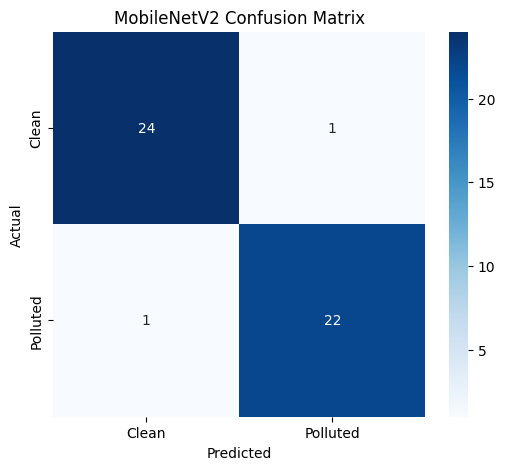

In [33]:
#MobileNetV2 Confusion Matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = mobilenet_model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig('/kaggle/working/mobilenet_confusion_matrix.png')

plt.show()

In [28]:
# MobileNetV2 Classification Report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       Clean       0.96      0.96      0.96        25
    Polluted       0.96      0.96      0.96        23

    accuracy                           0.96        48
   macro avg       0.96      0.96      0.96        48
weighted avg       0.96      0.96      0.96        48



In [34]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nFiles:")
for file in os.listdir():
    print(file)

Current Directory:
/kaggle/working

Files:
cnn_confusion_matrix.png
cnn_accuracy_curve.png
.virtual_documents
cnn_loss_curve.png
mobilenet_accuracy_curve.png
model_comparison.csv
mobilenet_confusion_matrix.png
mobilenet_loss_curve.png
